<a href="https://colab.research.google.com/github/mukul-mschauhan/textanalytics/blob/master/Session_3_%26_4_NLP_Disaster_Tweet_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚨 Disaster Tweet Detection — NLP with Deep Learning
### From Raw Tweets → Word2Vec → LSTM → Predictions

---

## 🧩 The Problem

Twitter is the world's fastest real-time news feed. During a disaster — earthquake, wildfire, flood — people tweet what they see. But not every dramatic tweet is a *real* emergency.

Compare these two tweets:
> 🔴 **"Wildfire near LA forces 10,000 residents to evacuate"** → Real disaster
>
> 🟡 **"My boss just ABLAZE'd me in that meeting 🔥"** → Just an expression

A human spots the difference instantly. Can a machine learn to do the same?

**Our goal:** Build an NLP classifier that reads a tweet and predicts: **Real Disaster (1)** or **Not a Disaster (0)**.

**Dataset:** ~10,000 hand-labelled tweets from [Kaggle: NLP Getting Started](https://www.kaggle.com/competitions/nlp-getting-started)

---

## 🗺️ Our Journey Today

```
Raw Tweets
    ↓
EDA + Feature Insights
    ↓
Text Cleaning Pipeline
    ↓
Baseline Models (BoW + TF-IDF + Logistic Regression)
    ↓
Word2Vec Embeddings (understanding word meaning)
    ↓
Deep Learning: Embedding → LSTM → Dense
    ↓
Improved LSTM with Dropout
    ↓
Model Comparison + Submission
```

---
## ⚙️ Step 1: Setup — Install & Import Everything

In [3]:
!pip install -q wordcloud pyspellchecker gensim tensorflow keras

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from wordcloud import WordCloud

# Word Embeddings
from gensim.models import Word2Vec

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print('✅ All libraries loaded!')

✅ All libraries loaded!


---
## 📂 Step 2: Load Data

**Dataset columns:**
| Column | Description |
|---|---|
| `id` | Unique tweet identifier |
| `keyword` | A keyword from the tweet (may be blank) |
| `location` | Where the tweet was sent from (often blank/noisy) |
| `text` | The actual tweet text |
| `target` | 🎯 **1 = Real Disaster, 0 = Not a Disaster** |

The test set has no `target` column — we predict it and submit to Kaggle.

In [5]:
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (7613, 5)  |  Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1


In [6]:
# Combine train + test for unified cleaning
# (We process both together so they get the same vocabulary)
combined = pd.concat([train, test], ignore_index=True)
print(f'Combined shape: {combined.shape}')

Combined shape: (10876, 5)


---
## 🔍 Step 3: Exploratory Data Analysis (EDA)

Before building any model, we need to **understand the data**.
Key questions:
- Is the dataset balanced or imbalanced?
- Which keywords strongly signal a disaster vs. not?
- How long are the tweets? Does length differ between classes?

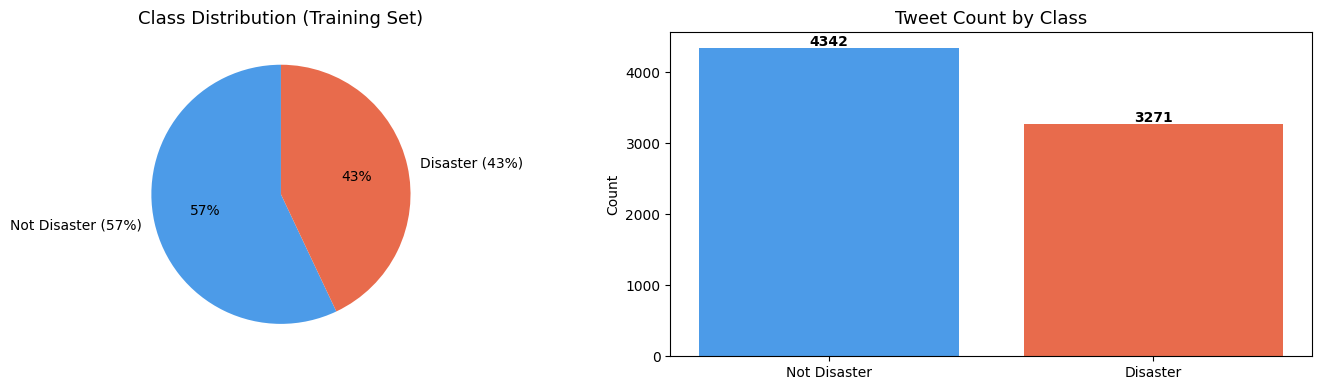

💡 Insight: Slight class imbalance (57% vs 43%). Not severe, but worth noting.


In [7]:
# ─── 3A: Class Distribution ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pie chart
train['target'].value_counts().plot(
    kind='pie', ax=axes[0],
    labels=['Not Disaster (57%)', 'Disaster (43%)'],
    colors=['#4C9BE8', '#E86B4C'],
    autopct='%1.0f%%', startangle=90
)
axes[0].set_ylabel('')
axes[0].set_title('Class Distribution (Training Set)', fontsize=13)

# Bar chart
counts = train['target'].value_counts()
axes[1].bar(['Not Disaster', 'Disaster'], counts.values, color=['#4C9BE8', '#E86B4C'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[1].set_title('Tweet Count by Class', fontsize=13)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('💡 Insight: Slight class imbalance (57% vs 43%). Not severe, but worth noting.')

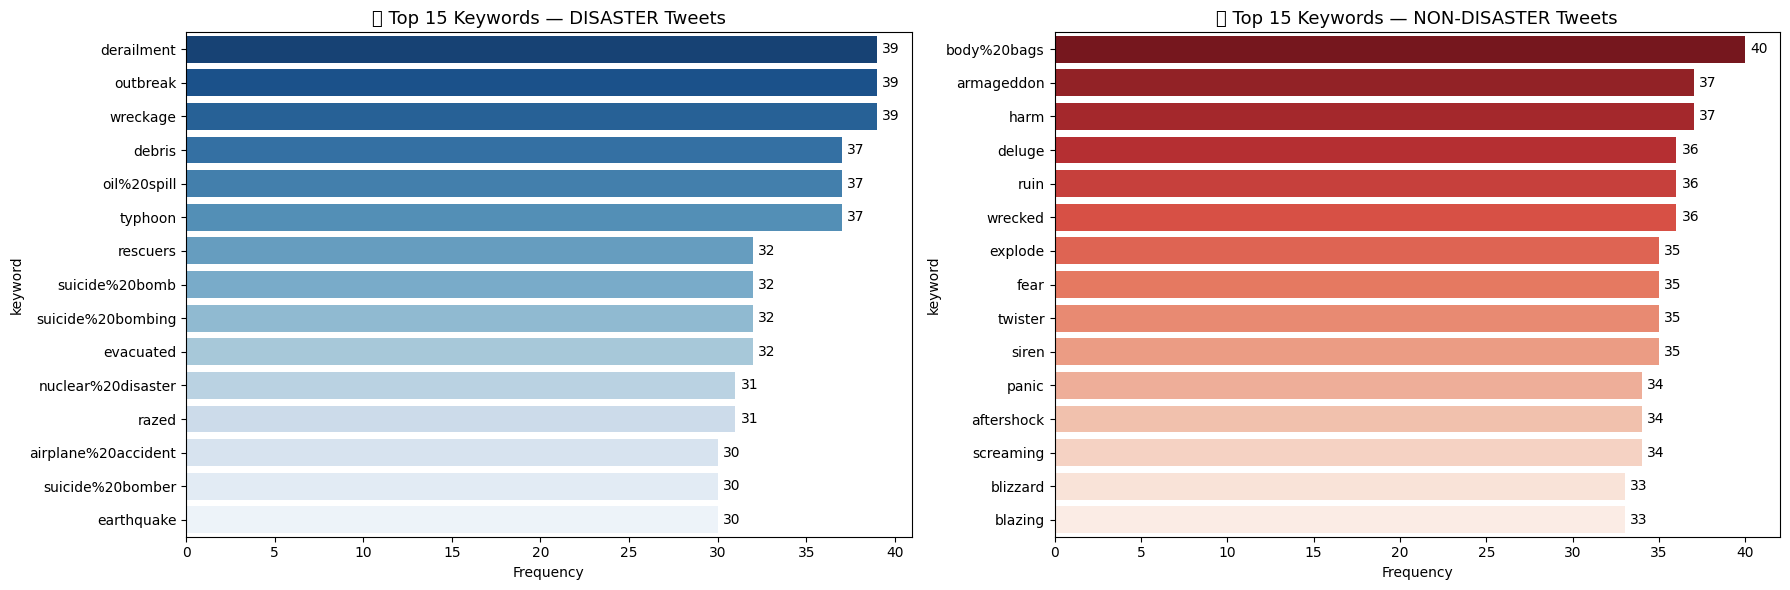

💡 Insight: "fatalities", "wreckage", "outbreak" → strong disaster signals.
   "body bagging", "armageddon" → often used metaphorically (non-disaster).


In [8]:
# ─── 3B: Top Keywords for Disaster vs. Not Disaster ───
disaster_kw     = train[train['target'] == 1]['keyword'].value_counts().head(15)
non_disaster_kw = train[train['target'] == 0]['keyword'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(y=disaster_kw.index, x=disaster_kw.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('🔴 Top 15 Keywords — DISASTER Tweets', fontsize=13)
axes[0].set_xlabel('Frequency')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 int(bar.get_width()), va='center')

sns.barplot(y=non_disaster_kw.index, x=non_disaster_kw.values, ax=axes[1], palette='Reds_r')
axes[1].set_title('🟢 Top 15 Keywords — NON-DISASTER Tweets', fontsize=13)
axes[1].set_xlabel('Frequency')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 int(bar.get_width()), va='center')

plt.tight_layout()
plt.show()

print('💡 Insight: "fatalities", "wreckage", "outbreak" → strong disaster signals.')
print('   "body bagging", "armageddon" → often used metaphorically (non-disaster).')

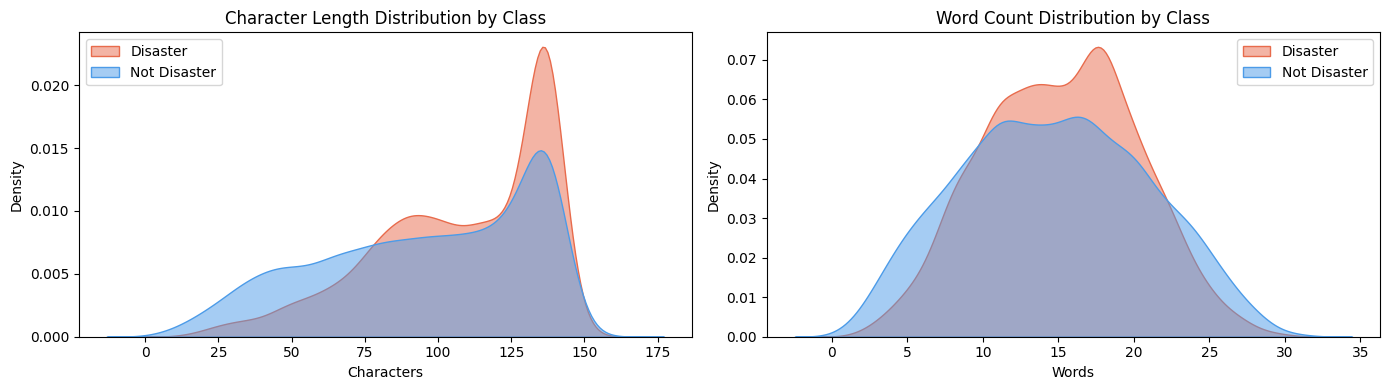

💡 Average words — Disaster: 15.2 | Non-Disaster: 14.7
   Disaster tweets tend to be slightly longer and more descriptive.


In [9]:
# ─── 3C: Tweet Length Distribution ───
combined['char_length'] = combined['text'].apply(len)
combined['word_count']  = combined['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Character length
for target, color, label in [(1, '#E86B4C', 'Disaster'), (0, '#4C9BE8', 'Not Disaster')]:
    subset = combined[combined['target'] == target]['char_length'].dropna()
    sns.kdeplot(subset, ax=axes[0], fill=True, color=color, label=label, alpha=0.5)
axes[0].set_title('Character Length Distribution by Class')
axes[0].set_xlabel('Characters')
axes[0].legend()

# Word count
for target, color, label in [(1, '#E86B4C', 'Disaster'), (0, '#4C9BE8', 'Not Disaster')]:
    subset = combined[combined['target'] == target]['word_count'].dropna()
    sns.kdeplot(subset, ax=axes[1], fill=True, color=color, label=label, alpha=0.5)
axes[1].set_title('Word Count Distribution by Class')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.tight_layout()
plt.show()

avg_words_disaster     = combined[combined['target']==1]['word_count'].mean()
avg_words_nondisaster  = combined[combined['target']==0]['word_count'].mean()
print(f'💡 Average words — Disaster: {avg_words_disaster:.1f} | Non-Disaster: {avg_words_nondisaster:.1f}')
print('   Disaster tweets tend to be slightly longer and more descriptive.')

---
## 🧹 Step 4: Text Cleaning Pipeline

Twitter data is the noisiest text you'll encounter:
- `@mentions`, `#hashtags`, URLs
- Emojis, punctuation, special characters
- Misspellings, ALL CAPS, repeated letters (`soooo`)

Our pipeline:
1. **Lowercase** — `Fire` and `fire` are the same word
2. **Remove URLs** — `http://...` adds noise, no meaning
3. **Remove @mentions and #hashtags** — metadata, not content
4. **Remove punctuation & numbers** — keep only letters
5. **Remove stopwords** — `the`, `is`, `a` add noise
6. **Lemmatize** — `evacuating` → `evacuate`

In [10]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_tweet(text):
    """
    Full tweet cleaning pipeline.
    Returns a clean string ready for tokenization.
    """
    text = str(text).lower()                          # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        # 2. Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)             # 3. Remove @mentions, #hashtags
    text = re.sub(r'[^a-z\s]', '', text)              # 4. Keep only letters + spaces
    tokens = text.split()                             # 5. Tokenize
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # 6. Remove stopwords
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]         # 7. Lemmatize
    return ' '.join(tokens)

# Apply to combined dataset
combined['clean_text'] = combined['text'].apply(clean_tweet)

# Preview: Before vs After
print('BEFORE:')
print(combined['text'].iloc[0])
print()
print('AFTER:')
print(combined['clean_text'].iloc[0])

BEFORE:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

AFTER:
deeds reason may allah forgive


---
## 📊 Step 5: Frequency Analysis & Word Cloud

**What words dominate the disaster tweets?**  
Looking at word frequency helps validate our cleaning and reveals key vocabulary the model will learn from.

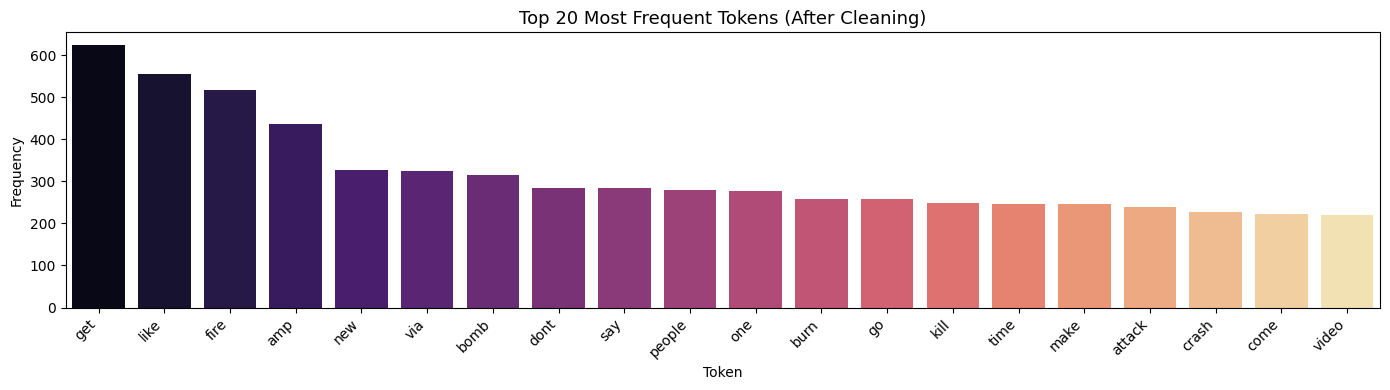

Total unique tokens: 13805


In [11]:
# Token frequency across all cleaned tweets
all_tokens = [token for text in combined['clean_text'].dropna()
              for token in text.split()]

freq_df = pd.DataFrame(
    FreqDist(all_tokens).items(),
    columns=['Token', 'Frequency']
).sort_values('Frequency', ascending=False)

# Plot top 20
plt.figure(figsize=(14, 4))
sns.barplot(data=freq_df.head(20), x='Token', y='Frequency', palette='magma')
plt.title('Top 20 Most Frequent Tokens (After Cleaning)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique tokens: {len(freq_df)}')

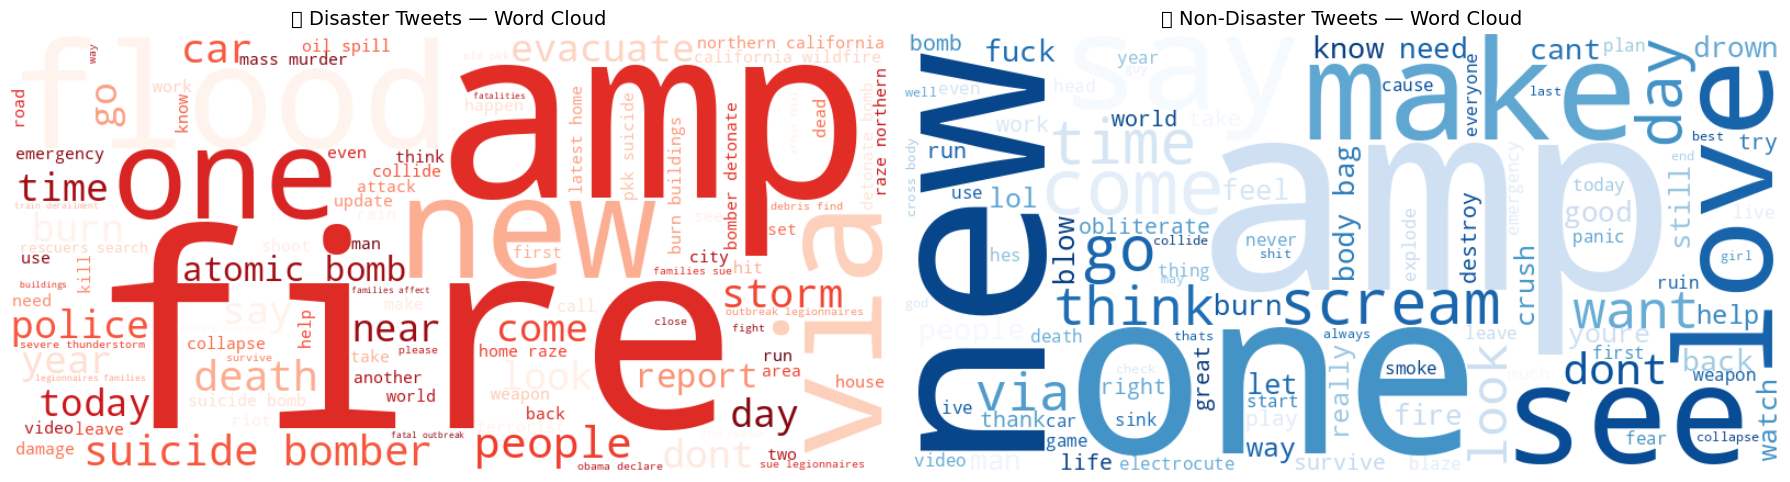

In [12]:
# Word Clouds: Disaster vs Non-Disaster
def make_wordcloud(texts, title, color):
    text_blob = ' '.join(texts.dropna())
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=color, max_words=100).generate(text_blob)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Only train rows have targets
train_clean = combined.iloc[:len(train)].copy()

plt.subplot(1, 2, 1)
make_wordcloud(train_clean[train_clean['target']==1]['clean_text'],
               '🔴 Disaster Tweets — Word Cloud', 'Reds')

plt.subplot(1, 2, 2)
make_wordcloud(train_clean[train_clean['target']==0]['clean_text'],
               '🟢 Non-Disaster Tweets — Word Cloud', 'Blues')

plt.tight_layout()
plt.show()

---
## ✂️ Step 6: Split Back into Train & Test

In [13]:
# Restore the original train/test split
train_clean = combined.iloc[:len(train)].copy()
test_clean  = combined.iloc[len(train):].copy()

X = train_clean['clean_text']
y = train_clean['target'].astype(int)
X_test_text = test_clean['clean_text']

print(f'Training samples: {len(X)}  |  Test samples: {len(X_test_text)}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Training samples: 7613  |  Test samples: 3263
Target distribution: {0: 4342, 1: 3271}


---
## 📏 Step 7: Baseline Models — BoW & TF-IDF + Logistic Regression

Before building a deep learning model, we establish **baselines**.

> 💡 A good rule in ML: *always try the simplest model first*. If your complex deep learning model can't beat logistic regression, something is wrong.

We use **cross-validation** (5-fold) here to get honest performance estimates — not just train-on-all, predict-test.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

results = {}

# ─── Baseline 1: Bag of Words ───
bow_vec   = CountVectorizer(min_df=3, stop_words='english')
X_bow     = bow_vec.fit_transform(X)
bow_scores = cross_val_score(LogisticRegression(max_iter=1000), X_bow, y, cv=5, scoring='f1')
results['BoW + LogReg'] = bow_scores.mean()
print(f'BoW  + LogReg  | F1 = {bow_scores.mean():.4f} ± {bow_scores.std():.4f}')

# ─── Baseline 2: TF-IDF ───
tfidf_vec   = TfidfVectorizer(min_df=3, stop_words='english', ngram_range=(1,2))
X_tfidf     = tfidf_vec.fit_transform(X)
tfidf_scores = cross_val_score(LogisticRegression(max_iter=1000), X_tfidf, y, cv=5, scoring='f1')
results['TF-IDF + LogReg'] = tfidf_scores.mean()
print(f'TFIDF + LogReg | F1 = {tfidf_scores.mean():.4f} ± {tfidf_scores.std():.4f}')

print('\n💡 These are our benchmarks. The deep learning model must beat ~0.75 F1 to be useful.')

BoW  + LogReg  | F1 = 0.5763 ± 0.0545
TFIDF + LogReg | F1 = 0.5484 ± 0.0608

💡 These are our benchmarks. The deep learning model must beat ~0.75 F1 to be useful.


In [15]:
# Train final BoW + TF-IDF models on full train, predict test (for Kaggle submission)
bow_vec_final   = CountVectorizer(min_df=3, stop_words='english')
X_train_bow     = bow_vec_final.fit_transform(X)
X_test_bow      = bow_vec_final.transform(X_test_text)
lr_bow = LogisticRegression(max_iter=1000)
lr_bow.fit(X_train_bow, y)
pred_bow = lr_bow.predict(X_test_bow)

submission_bow = pd.DataFrame({'id': test['id'], 'target': pred_bow})
submission_bow.to_csv('submission_bow.csv', index=False)
print('✅ BoW submission saved.')

✅ BoW submission saved.


---
## 🧠 Step 8: Word2Vec — Teaching Machines What Words Mean

BoW and TF-IDF treat words as **isolated IDs** — they have no idea that *"fire"* and *"blaze"* are related.

**Word2Vec** fixes this by learning **dense vector representations** (embeddings) where semantically similar words sit close together in vector space.

```
earthquake  →  [0.21, -0.83, 0.45, ...] (100 numbers)
tsunami     →  [0.19, -0.79, 0.41, ...] (close to earthquake!)
birthday    →  [0.88,  0.30, -0.22, ...] (far away from earthquake)
```

### How Word2Vec Learns
It uses a simple self-supervised trick: **predict a word from its neighbours (CBOW)** or **predict neighbours from a word (Skip-gram)**.

Skip-gram example:
> Sentence: `"people evacuated from the flood zone"`
>
> Given `"evacuated"` → predict: `"people"`, `"from"`, `"flood"`, `"zone"`

The model trains millions of such predictions → vectors gradually encode meaning.

### Key Parameters Explained
| Parameter | What it means | Our value |
|---|---|---|
| `vector_size` | How many numbers represent each word (embedding dimensions) | 100 |
| `window` | How many words left/right to look at for context | 5 |
| `min_count` | Ignore words appearing fewer than this many times | 2 |
| `sg` | Training algorithm: 1 = Skip-gram, 0 = CBOW | 1 (Skip-gram) |
| `epochs` | How many passes over the data during training | 10 |

> ⚠️ **Common mistake in the wild:** Setting `vector_size=10000` is wrong — that's larger than many vocabularies! Standard sizes are 50–300.

In [16]:
# Tokenize cleaned tweets for Word2Vec training
# Word2Vec expects a list of token lists (one per sentence)
train_tokens = [text.split() for text in X]

# Train Word2Vec
EMBEDDING_DIM = 100  # Each word → 100-dimensional vector

w2v_model = Word2Vec(
    sentences  = train_tokens,
    vector_size= EMBEDDING_DIM,   # Size of each word vector
    window     = 5,               # Context window: 5 words left + right
    min_count  = 2,               # Ignore rare words (< 2 occurrences)
    sg         = 1,               # Skip-gram (better for rare words)
    epochs     = 10,              # Training passes
    workers    = 4                # Parallel threads
)

print(f'Vocabulary size: {len(w2v_model.wv):,} unique words')
print(f'Vector shape for one word: {w2v_model.wv["fire"].shape}')

Vocabulary size: 4,824 unique words
Vector shape for one word: (100,)


In [17]:
# Sanity check: Words similar to 'fire' in our disaster tweet corpus
print('Words similar to "fire" in our corpus:')
for word, score in w2v_model.wv.most_similar('fire', topn=8):
    print(f'  {word:<20} similarity: {score:.4f}')

Words similar to "fire" in our corpus:
  alarm                similarity: 0.8761
  wild                 similarity: 0.8748
  evacuate             similarity: 0.8618
  truck                similarity: 0.8456
  bush                 similarity: 0.8370
  acres                similarity: 0.8288
  crew                 similarity: 0.8226
  rocky                similarity: 0.8177


In [18]:
# Average Word2Vec embedding per tweet
# Strategy: represent each tweet as the MEAN of its word vectors
# This collapses [n_words × 100] → [100] for each tweet

def tweet_to_vector(tokens, model, dim):
    """
    Convert a list of tokens to a single tweet-level vector
    by averaging the Word2Vec vectors of all known words.
    Returns a zero vector if no words are in the vocabulary.
    """
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(dim)

X_w2v = np.array([tweet_to_vector(tokens, w2v_model, EMBEDDING_DIM)
                  for tokens in train_tokens])

print(f'Shape of Word2Vec feature matrix: {X_w2v.shape}')
print('Each row = one tweet, each column = one embedding dimension')

Shape of Word2Vec feature matrix: (7613, 100)
Each row = one tweet, each column = one embedding dimension


In [19]:
# Baseline 3: Word2Vec + Logistic Regression
w2v_scores = cross_val_score(LogisticRegression(max_iter=1000), X_w2v, y, cv=5, scoring='f1')
results['Word2Vec + LogReg'] = w2v_scores.mean()
print(f'Word2Vec + LogReg | F1 = {w2v_scores.mean():.4f} ± {w2v_scores.std():.4f}')

# Summary so far
print()
print('=== Baseline Comparison ===')
for name, score in results.items():
    print(f'  {name:<25} F1 = {score:.4f}')

Word2Vec + LogReg | F1 = 0.6526 ± 0.0555

=== Baseline Comparison ===
  BoW + LogReg              F1 = 0.5763
  TF-IDF + LogReg           F1 = 0.5484
  Word2Vec + LogReg         F1 = 0.6526


---
## 🤖 Step 9: Deep Learning — LSTM for Sequence Classification

### Why Deep Learning?

BoW/TF-IDF and averaged Word2Vec **lose word order**.

> "The fire is out" ≠ "Out is the fire" — but BoW treats them identically.

**LSTMs (Long Short-Term Memory networks)** read text word-by-word, like a human, and remember context from earlier in the sentence. They capture **sequential meaning**.

---

### The Correct Deep Learning Pipeline for Text

```
Raw Tweet Text
     ↓
Keras Tokenizer  → maps each word to a unique integer
     ↓
Integer Sequences  e.g. ["fire" "broke" "out"] → [42, 187, 9]
     ↓
pad_sequences  → make all sequences the same length (e.g. 30)
     ↓
Embedding Layer  → converts integers to dense vectors (learns during training)
     ↓
LSTM Layer  → reads the sequence, captures context
     ↓
Dense(1, sigmoid)  → outputs probability [0, 1]
```

> ⚠️ **Important correction:** `pad_sequences` works on *integer sequences from a Tokenizer*, NOT on Word2Vec averaged vectors. The two are separate pipelines. We use the Keras Tokenizer pipeline for the LSTM model.

In [20]:
# ─── TOKENIZATION: Text → Integers ───
#
# Keras Tokenizer builds a vocabulary and maps each word to a unique integer index.
#   "fire"  → 42
#   "flood" → 78
#   ...and so on
#
# num_words=5000: keep only the 5000 most common words (cap vocab size)
# oov_token='<OOV>': any unknown word gets mapped to this special token

VOCAB_SIZE  = 5000
MAX_LEN     = 30    # Tweets rarely exceed 30 meaningful words after cleaning

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X)   # Learn vocabulary from training data ONLY

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Show an example
print('Original tweet:', X.iloc[0])
print('As integers:   ', X_train_seq[0])

Original tweet: deeds reason may allah forgive
As integers:    [3317, 418, 72, 2198, 1659]


In [21]:
# ─── PADDING: Make all sequences the same length ───
#
# Neural networks need fixed-size inputs.
# Tweets have different lengths → we pad shorter ones with 0s.
#
# padding='post'  → zeros added at the END   [1, 4, 9, 0, 0, 0]
# padding='pre'   → zeros added at the START [0, 0, 0, 1, 4, 9]
# truncating='post' → if longer than MAX_LEN, chop the tail

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f'Training matrix shape: {X_train_pad.shape}')
print('(rows = tweets, columns = time steps in the sequence)')
print()
print('First tweet padded to length 30:')
print(X_train_pad[0])

Training matrix shape: (7613, 30)
(rows = tweets, columns = time steps in the sequence)

First tweet padded to length 30:
[3317  418   72 2198 1659    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


---
## 🏗️ Step 10: Build Model 1 — Simple LSTM

### Architecture Explained — Layer by Layer

```
Input: [0, 42, 187, 9, 0, 0, ...] — integer sequence, length 30
         ↓
 ┌─────────────────────────────────────────────────────────────┐
 │  EMBEDDING LAYER                                            │
 │  Converts each integer → a learned dense vector             │
 │  42 → [0.21, -0.5, 0.83, ...]  (EMBEDDING_DIM numbers)     │
 │  Output shape: (batch, 30, 40)                              │
 └─────────────────────────────────────────────────────────────┘
         ↓
 ┌─────────────────────────────────────────────────────────────┐
 │  LSTM LAYER (64 units)                                      │
 │  Reads the sequence of 30 vectors, one step at a time       │
 │  At each step it updates a 'memory' (hidden state)          │
 │  Final output: one 64-dim summary of the whole tweet        │
 │  Output shape: (batch, 64)                                  │
 └─────────────────────────────────────────────────────────────┘
         ↓
 ┌─────────────────────────────────────────────────────────────┐
 │  DENSE LAYER (1 unit, sigmoid activation)                   │
 │  Takes the 64-dim summary → one probability                 │
 │  sigmoid: maps any number to [0, 1]                         │
 │  Output: e.g. 0.87 → very likely a disaster tweet           │
 └─────────────────────────────────────────────────────────────┘
```

### How the Embedding Layer Works
Think of it as a **lookup table**: index 42 → row 42 of a weight matrix of shape `(vocab_size, embedding_dim)`. These weights are **trained during backpropagation** — the model learns which words are important for disaster detection.

In [22]:
EMBEDDING_DIM_LSTM = 40   # Each word integer → 40-dimensional learnable vector

model_v1 = Sequential([
    # Layer 1: Embedding
    # input_dim  = VOCAB_SIZE+1: size of vocabulary (+1 for padding token 0)
    # output_dim = EMBEDDING_DIM_LSTM: vector size for each word
    # input_length = MAX_LEN: how long each input sequence is
    Embedding(input_dim=VOCAB_SIZE + 1,
              output_dim=EMBEDDING_DIM_LSTM,
              input_length=MAX_LEN),

    # Layer 2: LSTM with 64 memory units
    # Each unit maintains a hidden state across the 30 time steps
    LSTM(64),

    # Layer 3: Dense + Sigmoid
    # Sigmoid squishes the output to a probability between 0 and 1
    # > 0.5 = predict Disaster, <= 0.5 = predict Not Disaster
    Dense(1, activation='sigmoid')
])

# Compile
# optimizer = Adam: adaptive learning rate (smart gradient descent)
# loss = binary_crossentropy: standard loss for binary classification
# metrics = accuracy: what we monitor during training
model_v1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 📋 Reading the Model Summary Table

```
Layer (type)         Output Shape         Param #
─────────────────────────────────────────────────────
Embedding            (None, 30, 40)       200,040
LSTM                 (None, 64)           26,880
Dense                (None, 1)            65
─────────────────────────────────────────────────────
Total params: ~226,985
```

**What do these numbers mean?**

| Layer | Output Shape Explained | Param # Calculation |
|---|---|---|
| **Embedding** | `(batch, 30, 40)` → 30 words, each as 40-dim vector | `vocab_size × embedding_dim = 5001 × 40 = 200,040` |
| **LSTM** | `(batch, 64)` → sequence collapses to 64-dim summary | `4 × (64×40 + 64×64 + 64) ≈ 26,880` (LSTM has 4 gates) |
| **Dense** | `(batch, 1)` → single probability output | `64 weights + 1 bias = 65` |

**Why does LSTM have 4× the parameters?**  
An LSTM cell has 4 internal gates — **Forget gate**, **Input gate**, **Cell gate**, **Output gate** — each with its own weight matrix. This is what gives it memory.

In [23]:
from sklearn.model_selection import train_test_split

# Hold out 20% of train data for validation so we can track real performance
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y.values, test_size=0.2, random_state=42, stratify=y
)

# EarlyStopping: stop training if val_loss doesn't improve for 3 epochs
# This prevents overfitting and saves training time
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print(f'Training on {len(X_tr)} tweets, validating on {len(X_val)} tweets')

Training on 6090 tweets, validating on 1523 tweets


In [24]:
# Train Model V1
history_v1 = model_v1.fit(
    X_tr, y_tr,
    epochs          = 15,
    batch_size      = 64,          # Process 64 tweets at a time
    validation_data = (X_val, y_val),  # Monitor on held-out data
    callbacks       = [early_stop],
    verbose         = 1
)

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6202 - loss: 0.6471 - val_accuracy: 0.7873 - val_loss: 0.4882
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8090 - loss: 0.4607 - val_accuracy: 0.7866 - val_loss: 0.4950
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8614 - loss: 0.3537 - val_accuracy: 0.7945 - val_loss: 0.5003
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8923 - loss: 0.2918 - val_accuracy: 0.8004 - val_loss: 0.4989


---
## 📈 Step 11: Training Curves — Understanding What Happened

The training history tells us **how well learning progressed**.

**What to look for:**
- ✅ **Good:** Train loss ↓ and Val loss ↓ together → model is learning
- ⚠️ **Overfitting:** Train loss ↓ but Val loss ↑ → model memorising, not generalising
- ❌ **Underfitting:** Both losses flat and high → model hasn't learned anything

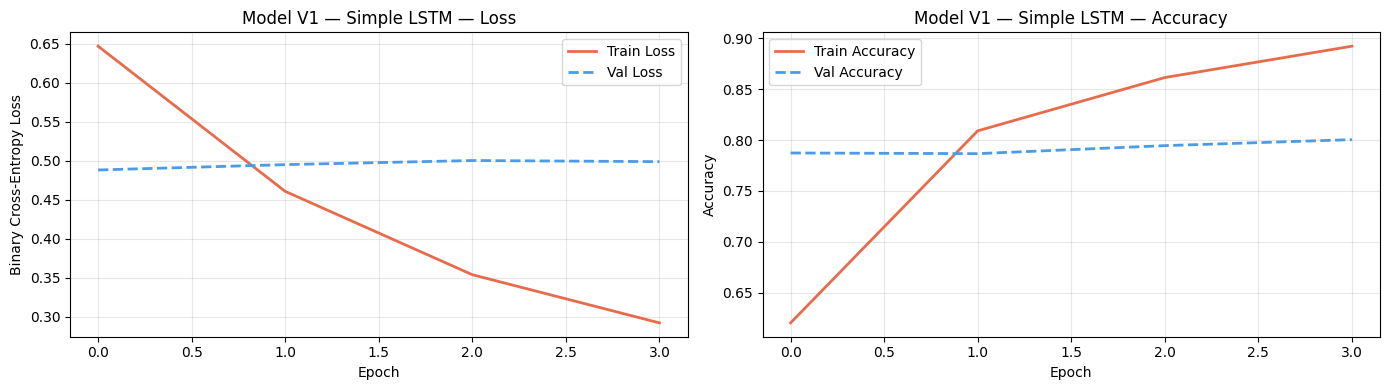

In [25]:
def plot_training_history(history, title='Model Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss plot
    axes[0].plot(history.history['loss'],     label='Train Loss',     color='#E86B4C', lw=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='#4C9BE8', lw=2, linestyle='--')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy plot
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#E86B4C', lw=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#4C9BE8', lw=2, linestyle='--')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history_v1, 'Model V1 — Simple LSTM')

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate on validation set
val_pred_proba = model_v1.predict(X_val)
val_pred       = (val_pred_proba > 0.5).astype(int).flatten()

print('=== Model V1 — Validation Performance ===')
print(classification_report(y_val, val_pred, target_names=['Not Disaster', 'Disaster']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Model V1 — Validation Performance ===
              precision    recall  f1-score   support

Not Disaster       0.78      0.88      0.82       869
    Disaster       0.80      0.67      0.73       654

    accuracy                           0.79      1523
   macro avg       0.79      0.77      0.78      1523
weighted avg       0.79      0.79      0.78      1523



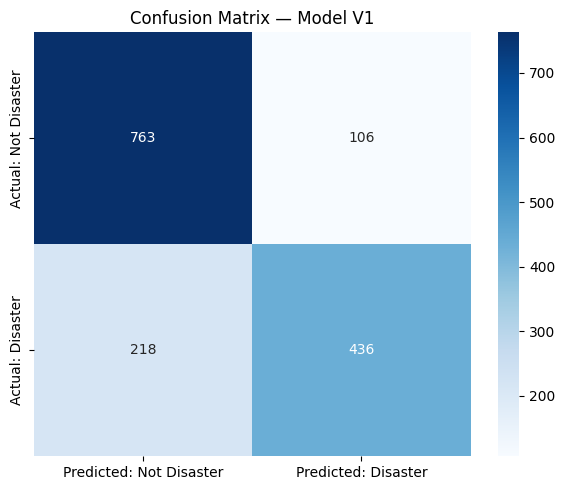

True Positives  (correctly caught disasters):  436
True Negatives  (correctly caught non-disaster): 763
False Positives (non-disaster predicted as disaster): 106  ← False Alarms
False Negatives (disaster missed entirely):   218  ← Dangerous!


In [27]:
# Confusion Matrix — visual breakdown of errors
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Not Disaster', 'Predicted: Disaster'],
            yticklabels=['Actual: Not Disaster', 'Actual: Disaster'])
plt.title('Confusion Matrix — Model V1')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correctly caught disasters):  {tp}')
print(f'True Negatives  (correctly caught non-disaster): {tn}')
print(f'False Positives (non-disaster predicted as disaster): {fp}  ← False Alarms')
print(f'False Negatives (disaster missed entirely):   {fn}  ← Dangerous!')

---
## 🚀 Step 12: Model V2 — Improved LSTM with Dropout

### What's Wrong with V1?
If V1 shows a gap between train and val accuracy → **overfitting**. The model is memorising training tweets rather than learning general patterns.

### How We Fix It

**Dropout** is the most powerful regularisation technique for neural networks.

> Imagine training a team where at each training session, random players are randomly *"switched off"*. The remaining players can't rely on any one teammate — so **everyone learns to do their job independently**. Result: a more robust team.

In neural networks:
- `Dropout(0.3)` randomly sets **30% of neurons to zero** during each training step
- Forces the network to learn **redundant, distributed representations**
- Dropout is **only active during training** — turned off at inference time

**V2 Architecture changes:**
- Dropout after Embedding (prevent over-reliance on specific word vectors)
- Larger LSTM (200 units vs 64) to capture richer patterns
- Dropout after LSTM (prevent overfitting on sequential patterns)

In [28]:
SENTENCE_LEN   = MAX_LEN         # 30
EMBED_FEATURES = 40              # word vector dimension

model_v2 = Sequential([
    # Embedding: integer → 40-dim dense vector (same as V1)
    Embedding(input_dim=VOCAB_SIZE + 1,
              output_dim=EMBED_FEATURES,
              input_length=SENTENCE_LEN),

    # Dropout(0.3): randomly zero out 30% of embedding outputs
    # Prevents the model from over-relying on specific word vectors
    Dropout(0.3),

    # Larger LSTM: 200 units capture richer context than 64
    # More units = more capacity to distinguish subtle tweet patterns
    LSTM(200),

    # Dropout again: regularise the LSTM's output representations
    Dropout(0.3),

    # Output: same as V1
    Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 📋 Reading the V2 Model Summary

| Layer | Output Shape | Param # | What it does |
|---|---|---|---|
| **Embedding** | `(None, 30, 40)` | ~200,040 | Maps each of 30 words to a 40-dim learnable vector |
| **Dropout(0.3)** | `(None, 30, 40)` | 0 | Randomly zeros 30% of embeddings — no learnable params! |
| **LSTM(200)** | `(None, 200)` | ~192,800 | Reads 30 steps, outputs 200-dim tweet summary |
| **Dropout(0.3)** | `(None, 200)` | 0 | Zeros 30% of LSTM outputs — no learnable params! |
| **Dense(1)** | `(None, 1)` | 201 | Final probability output |

**LSTM(200) parameter calculation:**  
`4 × (units × input_dim + units × units + units)`  
`= 4 × (200×40 + 200×200 + 200) = 4 × (8000 + 40000 + 200) = 192,800`

> The **4×** multiplier is because an LSTM has 4 gates:  
> **f** (forget what's irrelevant) | **i** (what new info to store) | **g** (candidate values) | **o** (what to output)

**Key insight:** Dropout layers have **0 parameters** — they don't learn anything. They're just a regularisation mechanism applied during training.

In [29]:
early_stop_v2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_v2 = model_v2.fit(
    X_tr, y_tr,
    epochs          = 15,
    batch_size      = 64,
    validation_data = (X_val, y_val),
    callbacks       = [early_stop_v2],
    verbose         = 1
)

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5875 - loss: 0.6750 - val_accuracy: 0.7242 - val_loss: 0.5653
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7947 - loss: 0.4738 - val_accuracy: 0.7938 - val_loss: 0.4616
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8496 - loss: 0.3699 - val_accuracy: 0.7866 - val_loss: 0.4905
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8793 - loss: 0.3114 - val_accuracy: 0.7774 - val_loss: 0.5118
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9020 - loss: 0.2661 - val_accuracy: 0.7807 - val_loss: 0.5097


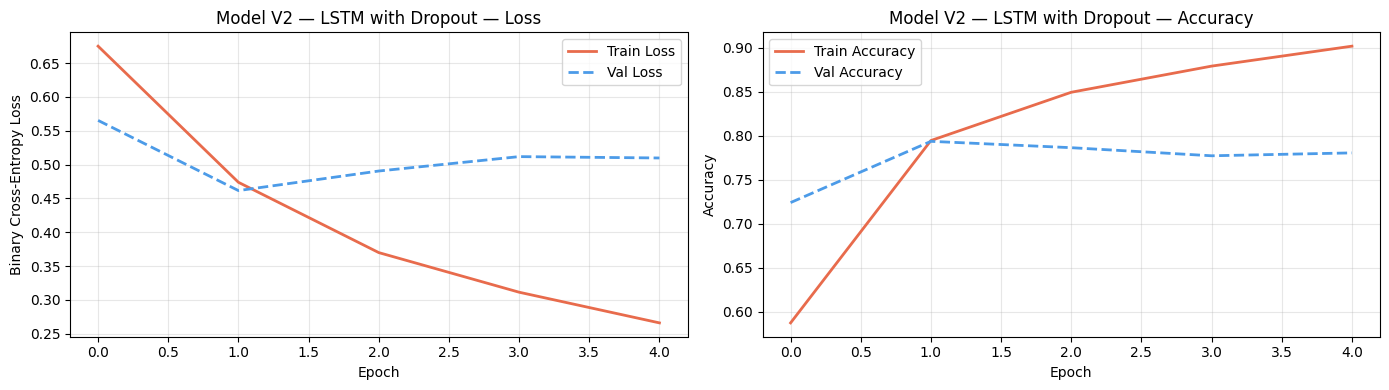

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Model V2 — Validation Performance ===
              precision    recall  f1-score   support

Not Disaster       0.76      0.93      0.84       869
    Disaster       0.87      0.61      0.72       654

    accuracy                           0.79      1523
   macro avg       0.82      0.77      0.78      1523
weighted avg       0.81      0.79      0.79      1523



In [30]:
plot_training_history(history_v2, 'Model V2 — LSTM with Dropout')

# Evaluate V2
val_pred_v2 = (model_v2.predict(X_val) > 0.5).astype(int).flatten()
print('=== Model V2 — Validation Performance ===')
print(classification_report(y_val, val_pred_v2, target_names=['Not Disaster', 'Disaster']))

---
## 🏆 Step 13: Final Model Comparison

Let's put every model head-to-head on the **same validation set**.

In [31]:
from sklearn.metrics import f1_score, accuracy_score

# BoW + LogReg on validation split (refit)
bow_final = CountVectorizer(min_df=3, stop_words='english')
X_all_bow = bow_final.fit_transform(X)
X_tr_bow, X_val_bow = X_all_bow[:len(X_tr)], X_all_bow[len(X_tr):]

# Rebuild val indices properly for sklearn
from sklearn.model_selection import train_test_split
X_tr_idx, X_val_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42, stratify=y)

bow_v = CountVectorizer(min_df=3, stop_words='english')
bow_v.fit(X.iloc[X_tr_idx])
lr_bow_v = LogisticRegression(max_iter=1000)
lr_bow_v.fit(bow_v.transform(X.iloc[X_tr_idx]), y.iloc[X_tr_idx])
pred_bow_v = lr_bow_v.predict(bow_v.transform(X.iloc[X_val_idx]))

tfidf_v = TfidfVectorizer(min_df=3, stop_words='english', ngram_range=(1,2))
tfidf_v.fit(X.iloc[X_tr_idx])
lr_tfidf_v = LogisticRegression(max_iter=1000)
lr_tfidf_v.fit(tfidf_v.transform(X.iloc[X_tr_idx]), y.iloc[X_tr_idx])
pred_tfidf_v = lr_tfidf_v.predict(tfidf_v.transform(X.iloc[X_val_idx]))

y_val_true = y.iloc[X_val_idx].values

comparison = {
    'BoW + LogReg':       {'f1': f1_score(y_val_true, pred_bow_v),   'acc': accuracy_score(y_val_true, pred_bow_v)},
    'TF-IDF + LogReg':    {'f1': f1_score(y_val_true, pred_tfidf_v), 'acc': accuracy_score(y_val_true, pred_tfidf_v)},
    'LSTM V1 (Simple)':   {'f1': f1_score(y_val, val_pred),          'acc': accuracy_score(y_val, val_pred)},
    'LSTM V2 (Dropout)':  {'f1': f1_score(y_val, val_pred_v2),       'acc': accuracy_score(y_val, val_pred_v2)},
}

comp_df = pd.DataFrame(comparison).T
comp_df = comp_df.sort_values('f1', ascending=False)

# Display
print('=== MODEL COMPARISON (Validation Set) ===')
print(f'{"Model":<25} {"F1 Score":>10} {"Accuracy":>10}')
print('-' * 47)
for model_name, row in comp_df.iterrows():
    marker = '🏆' if model_name == comp_df.index[0] else '  '
    print(f'{marker} {model_name:<23} {row["f1"]:>10.4f} {row["acc"]:>10.4f}')

=== MODEL COMPARISON (Validation Set) ===
Model                       F1 Score   Accuracy
-----------------------------------------------
🏆 TF-IDF + LogReg             0.7529     0.8056
   BoW + LogReg                0.7466     0.7905
   LSTM V1 (Simple)            0.7291     0.7873
   LSTM V2 (Dropout)           0.7171     0.7938


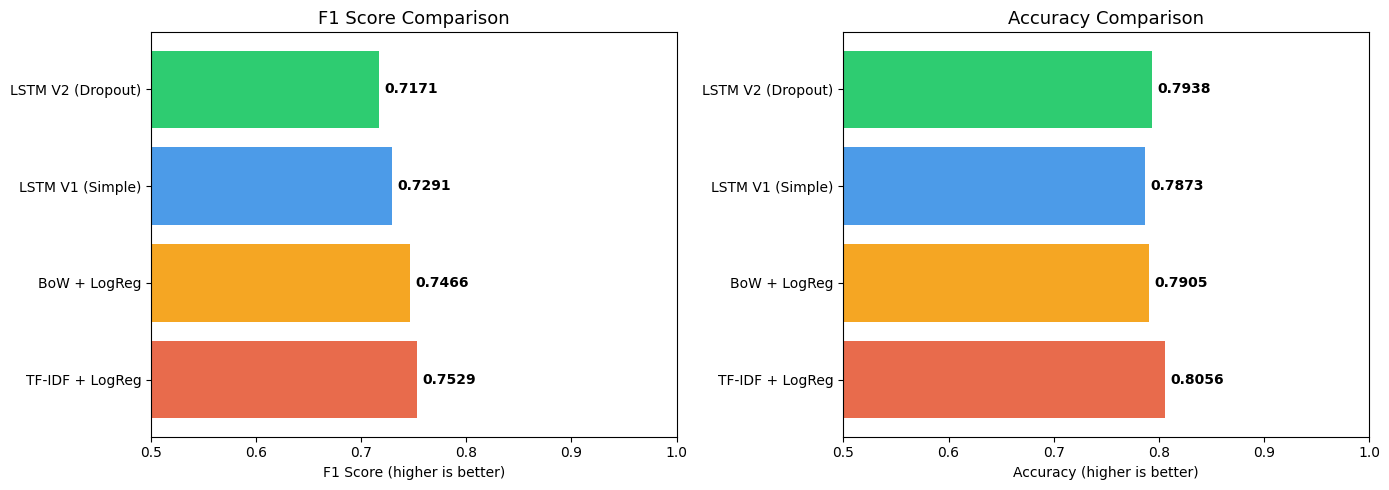

In [32]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E86B4C', '#F5A623', '#4C9BE8', '#2ECC71']

axes[0].barh(comp_df.index, comp_df['f1'], color=colors)
axes[0].set_xlim(0.5, 1.0)
axes[0].set_title('F1 Score Comparison', fontsize=13)
axes[0].set_xlabel('F1 Score (higher is better)')
for i, v in enumerate(comp_df['f1']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

axes[1].barh(comp_df.index, comp_df['acc'], color=colors)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title('Accuracy Comparison', fontsize=13)
axes[1].set_xlabel('Accuracy (higher is better)')
for i, v in enumerate(comp_df['acc']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📤 Step 14: Generate Final Submission

In [33]:
# Use the best model to predict on the actual test set
best_model = model_v2  # Change to model_v1 if V1 performed better

test_pred_proba = best_model.predict(X_test_pad)
test_pred_labels = (test_pred_proba.flatten() > 0.5).astype(int)

submission = pd.DataFrame({'id': test['id'], 'target': test_pred_labels})
submission.to_csv('submission_lstm.csv', index=False)

print('✅ Submission saved: submission_lstm.csv')
print(f'Prediction breakdown: {submission["target"].value_counts().to_dict()}')
submission.head(10)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Submission saved: submission_lstm.csv
Prediction breakdown: {0: 2406, 1: 857}


,id,target
0,0,0
1,2,0
2,3,1
3,9,0
4,11,1
5,12,0
6,21,0
7,22,0
8,27,0
9,29,0


---
## 🧠 Step 15: What We Learned — Mental Models to Take Away

### The NLP Feature Evolution

```
BoW / TF-IDF          Word2Vec                  LSTM
───────────           ──────────                ─────
Word presence         Word meaning              Word order + meaning
Sparse (many 0s)      Dense (all filled)        Sequence-aware
No context            Static context            Dynamic context
"fire"=integer        "fire"≈"blaze"            "building on fire"≠"fired"
Fast                  Medium                    Slow (but powerful)
```

### The Deep Learning Stack Decoded

| Layer | Analogy | What it actually does |
|---|---|---|
| **Embedding** | Dictionary → meaning | Maps word ID to learnable dense vector |
| **Dropout** | Study without your notes | Forces redundant learning, prevents memorisation |
| **LSTM** | Reading comprehension | Processes words in order, remembers context |
| **Dense + Sigmoid** | Judge | Takes the LSTM's understanding and decides: disaster or not? |